# fastDSA tutorial
In this notebook we demonstrate a minimal end-to-end workflow for comparing two collections of time series using fastDSA.

## Imports and API entrypoints
- `SimDistConfig`: configuration object that controls delay embedding, rank selection, optimization hyperparameters, and the similarity method.
  
- `FastDSASimilarity`: high-level pipeline that computes DMD operators (with delay embedding and optional SVHT rank selection) and evaluates a similarity score.

In [4]:
from fastDSA.simdist import SimDistConfig, FastDSASimilarity
import numpy as np
from scipy.integrate import solve_ivp
from sklearn.manifold import MDS
import matplotlib.pyplot as plt

## Load data or generate synthetic trajectories

This cell prepares two datasets of trajectories:

- Dataset A and Dataset B can be loaded from disk (each trial stored as a .npy file), or

- generated synthetically from two nonlinear 2D dynamical systems using solve_ivp.

The loader assumes each .npy file is shaped (T, n_features) where T is the number of time points. The synthetic option produces a small set of trajectories for each system with randomized initial conditions, which is useful for validating the pipeline without external data.

At the end of the cell we print how many trajectories were loaded/generated and the shape of an example trial.

In [5]:
use_synthetic = True  # <-- set to False to load from folders

folder_A = ""   # folder of .npy files for Dataset A (if not synthetic)
folder_B = ""   # folder of .npy files for Dataset B (if not synthetic)

def load_trajs_from_folder(folder: str):
    """Load all .npy files in a folder as a list of arrays (T, n_features).\"\"\"\"\"\""""
    path = Path(folder)
    if not path.exists():
        raise FileNotFoundError(f"Folder not found: {folder}")
    trajs = []
    for f in sorted(path.glob("*.npy")):
        arr = np.load(f, allow_pickle=False)
        if arr.ndim != 2:
            raise ValueError(f'File {f} must be 2D (T, n_features). Got shape {arr.shape}.' )
        trajs.append(arr)
    if len(trajs) == 0:
        raise ValueError(f'No .npy files found in {folder}')
    return trajs

# --- Synthetic demo systems (2D) ---
def system_a(t, state, eps=0.5):
    x, y = state
    dx = -1.0 * x + eps * x * y
    dy = -2.0 * y - eps * x**2
    return [dx, dy]

def system_b(t, state, eps=0.5):
    x, y = state
    dx = -1.5 * x + 0.5 * y - eps * x**2
    dy = 0.5 * x - 1.5 * y - eps * y**2
    # dx = -1.0 * x + eps * x * y
    # dy = -3.0 * y - eps * x**2
    return [dx, dy]

def generate_trajectory(system, x0, T=10.0, dt=0.01, eps=0.5):
    t_eval = np.arange(0, T, dt)
    sol = solve_ivp(system, (0, T), x0, t_eval=t_eval, args=(eps,))
    return sol.y.T  # (T, 2)

if use_synthetic:
    # Build small demo sets
    num_per_set = 10
    T=10.0; dt=0.01
    eps=0.5
    rng = np.random.default_rng(42)

    dataset_A = [generate_trajectory(system_a, rng.uniform(-4,4,size=2), T=T, dt=dt, eps=eps) for _ in range(num_per_set)]
    dataset_B = [generate_trajectory(system_b, rng.uniform(-4,4,size=2), T=T, dt=dt, eps=eps) for _ in range(num_per_set)]
else:
    dataset_A = load_trajs_from_folder(folder_A)
    dataset_B = load_trajs_from_folder(folder_B)

print(f"Loaded {len(dataset_A)} trajectories for A, {len(dataset_B)} for B.")
print(f'Example shape A[0]: {dataset_A[0].shape}.')

Loaded 10 trajectories for A, 10 for B.
Example shape A[0]: (1000, 2).


## Compute fastDSA pairwise distances across trials

fastDSA expects each trial in the shape `(channels, timepoints)`, while our synthetic generator (and typical `.npy` storage) uses `(timepoints, features)`. We therefore transpose each trajectory to match the package convention.

We then configure and run fastDSA in two stages:

1. Global rank selection (SVHT):
We call `fit_score` once on the full datasets with `rank=None`. This triggers automatic rank detection via SVHT and returns a single `used_rank` that is consistent across both datasets. Using a fixed rank improves stability and comparability for pairwise distances.

2. Pairwise distance matrix:
With `rank=used_rank`, we compute fastDSA distances for every pair of trials across the combined set `A ∪ B`, producing a symmetric distance matrix `dist_mat` of shape `(N, N)`.

You can switch `method` to compare different similarity backends supported by the package (e.g., `"ro"`, `"rim"`, `"land"`).

In [6]:
def to_channels_time(traj_Tn: np.ndarray) -> np.ndarray:
    """
    Convert (T, n_features) -> (channels, timepoints).
    Your package expects (channels, timepoints).
    """
    if traj_Tn.ndim != 2:
        raise ValueError(f"Trajectory must be 2D (T, n_features). Got {traj_Tn.shape}")
    return traj_Tn.T


# Convert your datasets
dataset_A_ct = [to_channels_time(tr) for tr in dataset_A]
dataset_B_ct = [to_channels_time(tr) for tr in dataset_B]


method = 'ro'

device = "cuda" #if torch.cuda.is_available() else "cpu"
method = "ro"          # or "rim", "land"
iters = 200
lr = 1e-2
n_delays = 15
delay_interval = 1

all_trials = dataset_A_ct + dataset_B_ct  # each is (C, T)
N = len(all_trials)

# 1) One call to get a global rank (inside your package)
cfg_rank = SimDistConfig(
    n_delays=n_delays,
    delay_interval=delay_interval,
    rank=None,
    method=method,
    iters=50,      # cheap run; rank detection is the point
    lr=lr,
    device=device,
    verbose=True,
)
sim_rank = FastDSASimilarity(cfg_rank)

_, used_rank = sim_rank.fit_score(dataset_A_ct, dataset_B_ct)
print("Global rank selected:", used_rank)

# 2) Pairwise distances with fixed rank
cfg = SimDistConfig(
    n_delays=n_delays,
    delay_interval=delay_interval,
    rank=used_rank,          # fixed for all pairwise calls
    method=method,
    iters=iters,
    lr=lr,
    eta=None,
    gamma=0.98,
    n_Cmats=2,
    device=device,
    verbose=False,
)
sim = FastDSASimilarity(cfg)

dist_mat = np.zeros((N, N), dtype=float)
for i in range(N):
    for j in range(i + 1, N):
        d, _ = sim.fit_score(all_trials[i], all_trials[j])
        dist_mat[i, j] = dist_mat[j, i] = float(d)


[fastDSA] Detected global rank via SVHT: 14
Optimal C computed for group O(n) with regularization and low-rank approximation.
Global rank selected: 14


## Embed trials with MDS and visualize separation

Given the pairwise fastDSA distance matrix, we compute a 2D embedding using Multidimensional Scaling (MDS) with `dissimilarity="precomputed"`. This produces 2D coordinates for each trial such that Euclidean distances in the embedding reflect fastDSA dissimilarities as closely as possible.

Finally, we plot the embedded points and color them by dataset membership (A vs B). The figure is saved to both PDF and SVG for inclusion in reports, papers, or documentation, and also displayed inline in the notebook.

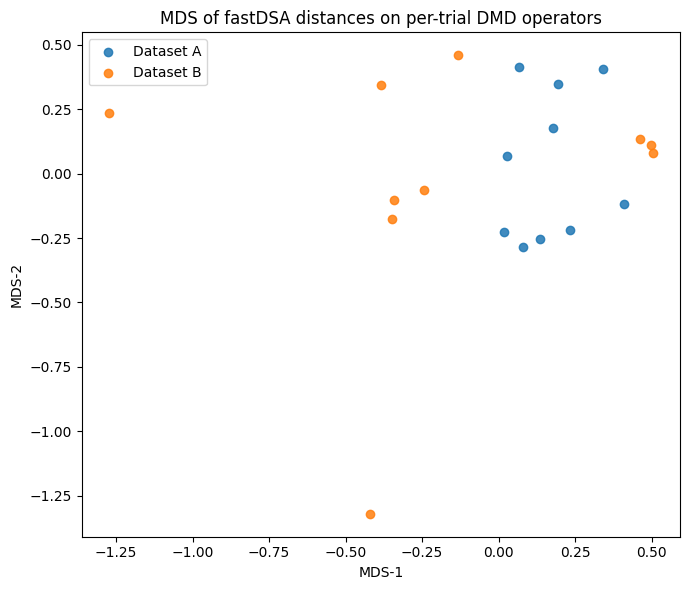

In [ ]:
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
coords = mds.fit_transform(dist_mat)

nA = len(dataset_A_ct)
labels = np.array([0] * nA + [1] * (len(dataset_B_ct)))

plt.figure(figsize=(7, 6))
plt.scatter(coords[labels == 0, 0], coords[labels == 0, 1], label="Dataset A", alpha=0.85)
plt.scatter(coords[labels == 1, 0], coords[labels == 1, 1], label="Dataset B", alpha=0.85)
plt.xlabel("MDS-1")
plt.ylabel("MDS-2")
plt.title("MDS of fastDSA distances on per-trial DMD operators")
plt.legend()
plt.tight_layout()

plt.savefig(".pdf", bbox_inches="tight")
plt.savefig(".svg", bbox_inches="tight")
plt.show()